In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
Path.cwd()

PosixPath('/Users/jinghongmiao/Code/mvt-code/v3/src/analysis')

In [14]:
# read v3/outputs/weeks_summary_100_500.csv, weeks_summary_p10, weeks_summary_p20
summary_4 = pd.read_csv("../../outputs/weeks_10_50_summary.csv")
summary_2 = pd.read_csv("../../outputs/weeks_1_5_summary.csv")
summary_3 = pd.read_csv("../../outputs/weeks_5_25_summary.csv")
summary_1 = pd.read_csv("../../outputs/weeks_0.1_0.5_summary.csv")
# summary_2 = pd.read_csv("../../outputs/weeks_100_500_summary.csv")
# summary_3 = pd.read_csv("../../outputs/weeks_50_250_summary.csv")
# summary_4 = pd.read_csv("../../outputs/weeks_200_1000_summary.csv")

summary_5 = pd.read_csv("../../outputs/weeks_10_100_summary.csv")
# summary_6 = pd.read_csv("../../outputs/weeks_10_250_summary.csv")
# summary_7 = pd.read_csv("../../outputs/weeks_10_500_summary.csv")
# summary_8 = pd.read_csv("../../outputs/weeks_10_1000_summary.csv")

# summary_9 = pd.read_csv("../../outputs/weeks_25_50_summary.csv")
# summary_10 = pd.read_csv("../../outputs/weeks_25_100_summary.csv")
# summary_11 = pd.read_csv("../../outputs/weeks_25_250_summary.csv")
summary_12 = pd.read_csv("../../outputs/weeks_10_250_summary.csv")
summary_13 = pd.read_csv("../../outputs/weeks_10_1000_summary.csv")

# merge by stacking the rows
# summary_all = pd.concat([summary_1, summary_2, summary_3, summary_4, summary_5, summary_6, summary_7, summary_8, summary_9, summary_10, summary_11, summary_12, summary_13], ignore_index=True)
summary_all = pd.concat([summary_1, summary_2, summary_3, summary_5, summary_12, summary_13], ignore_index=True)
summary_all.head()


,instance,hour_penalty,leader_penalty,cumu_hours_diff,cumu_hours_max,cumu_hours_mean,cumu_hours_median,cumu_hours_min,cumu_hours_std,cumu_leader_days_diff,...,cumu_leader_days_median,cumu_leader_days_min,cumu_leader_days_std,cumu_leaders_diff,cumu_leaders_max,cumu_leaders_mean,cumu_leaders_median,cumu_leaders_min,cumu_leaders_std,total_travel
0,c101_even_4week,0.1,0.5,127.5,127.5,67.96,73.0,0.0,38.265298,20.0,...,0.0,0.0,5.095016,37.0,37.0,4.0,0.0,0.0,9.145089,31814.0
1,c101_even_4week_weekly_hours,0.1,0.5,125.5,125.5,67.96,71.5,0.0,38.103891,20.0,...,0.0,0.0,4.953210,37.0,37.0,4.0,0.0,0.0,8.559516,31921.0
2,c101_even_4week_weekly_hours_running_day,0.1,0.5,122.5,122.5,67.96,69.0,0.0,37.854156,17.0,...,0.0,0.0,4.703841,32.0,32.0,4.0,0.0,0.0,8.154128,31912.0
3,c101_even_4week_weekly_hours_weekly_leaders_day,0.1,0.5,122.5,122.5,67.96,71.0,0.0,37.900627,18.0,...,0.0,0.0,4.823412,33.0,33.0,4.0,0.0,0.0,8.270923,31981.0
4,c201_even_4week,0.1,0.5,123.0,123.0,67.96,69.5,0.0,35.611687,20.0,...,0.0,0.0,4.862350,37.0,37.0,4.0,0.0,0.0,8.263517,31350.0


In [15]:
# keep only columns instance, total_travel, cumu_hours_diff, cumu_leader_days_diff, cumu_leaders_diff
summary_all = summary_all[['instance', 'total_travel', 'cumu_hours_diff', 'cumu_leader_days_diff', 'cumu_leaders_diff', 'hour_penalty', 'leader_penalty']]
summary_all.head(12)

,instance,total_travel,cumu_hours_diff,cumu_leader_days_diff,cumu_leaders_diff,hour_penalty,leader_penalty
0,c101_even_4week,31814.0,127.5,20.0,37.0,0.1,0.5
1,c101_even_4week_weekly_hours,31921.0,125.5,20.0,37.0,0.1,0.5
2,c101_even_4week_weekly_hours_running_day,31912.0,122.5,17.0,32.0,0.1,0.5
3,c101_even_4week_weekly_hours_weekly_leaders_day,31981.0,122.5,18.0,33.0,0.1,0.5
4,c201_even_4week,31350.0,123.0,20.0,37.0,0.1,0.5
5,c201_even_4week_weekly_hours,31440.0,120.5,18.0,32.0,0.1,0.5
6,c201_even_4week_weekly_hours_running_day,31415.0,119.0,18.0,34.0,0.1,0.5
7,c201_even_4week_weekly_hours_weekly_leaders_day,31420.0,119.0,18.0,31.0,0.1,0.5
8,r101_even_4week,24923.0,121.0,18.0,34.0,0.1,0.5
9,r101_even_4week_weekly_hours,25077.0,92.5,17.0,28.0,0.1,0.5


In [16]:
def split_instance(instance: str) -> tuple[str, str]:
    if "_4week_" in instance:
        base_instance, model = instance.split("_4week_", maxsplit=1)
        return base_instance, model
    elif instance.endswith("_4week"):
        base_instance = instance.removesuffix("_4week")
        return base_instance, "baseline"
    else:
        return instance, "other"

summary_all[["prefix", "model"]] = summary_all["instance"].apply(
    lambda x: pd.Series(split_instance(x))
)

summary_all.head(12)

,instance,total_travel,cumu_hours_diff,cumu_leader_days_diff,cumu_leaders_diff,hour_penalty,leader_penalty,prefix,model
0,c101_even_4week,31814.0,127.5,20.0,37.0,0.1,0.5,c101_even,baseline
1,c101_even_4week_weekly_hours,31921.0,125.5,20.0,37.0,0.1,0.5,c101_even,weekly_hours
2,c101_even_4week_weekly_hours_running_day,31912.0,122.5,17.0,32.0,0.1,0.5,c101_even,weekly_hours_running_day
3,c101_even_4week_weekly_hours_weekly_leaders_day,31981.0,122.5,18.0,33.0,0.1,0.5,c101_even,weekly_hours_weekly_leaders_day
4,c201_even_4week,31350.0,123.0,20.0,37.0,0.1,0.5,c201_even,baseline
5,c201_even_4week_weekly_hours,31440.0,120.5,18.0,32.0,0.1,0.5,c201_even,weekly_hours
6,c201_even_4week_weekly_hours_running_day,31415.0,119.0,18.0,34.0,0.1,0.5,c201_even,weekly_hours_running_day
7,c201_even_4week_weekly_hours_weekly_leaders_day,31420.0,119.0,18.0,31.0,0.1,0.5,c201_even,weekly_hours_weekly_leaders_day
8,r101_even_4week,24923.0,121.0,18.0,34.0,0.1,0.5,r101_even,baseline
9,r101_even_4week_weekly_hours,25077.0,92.5,17.0,28.0,0.1,0.5,r101_even,weekly_hours


In [17]:
valid_models = {
    "baseline",
    # "add_depot",
    "weekly_hours",
    # "add_depot_weekly_hours",
    "weekly_hours_weekly_leaders_day",
    # "add_depot_weekly_hours_weekly_leaders",
    "weekly_hours_running_day",
    # "add_depot_weekly_hours_running"
}
summary_filtered = summary_all[summary_all["model"].isin(valid_models)].copy()
summary_filtered.head(12)

,instance,total_travel,cumu_hours_diff,cumu_leader_days_diff,cumu_leaders_diff,hour_penalty,leader_penalty,prefix,model
0,c101_even_4week,31814.0,127.5,20.0,37.0,0.1,0.5,c101_even,baseline
1,c101_even_4week_weekly_hours,31921.0,125.5,20.0,37.0,0.1,0.5,c101_even,weekly_hours
2,c101_even_4week_weekly_hours_running_day,31912.0,122.5,17.0,32.0,0.1,0.5,c101_even,weekly_hours_running_day
3,c101_even_4week_weekly_hours_weekly_leaders_day,31981.0,122.5,18.0,33.0,0.1,0.5,c101_even,weekly_hours_weekly_leaders_day
4,c201_even_4week,31350.0,123.0,20.0,37.0,0.1,0.5,c201_even,baseline
5,c201_even_4week_weekly_hours,31440.0,120.5,18.0,32.0,0.1,0.5,c201_even,weekly_hours
6,c201_even_4week_weekly_hours_running_day,31415.0,119.0,18.0,34.0,0.1,0.5,c201_even,weekly_hours_running_day
7,c201_even_4week_weekly_hours_weekly_leaders_day,31420.0,119.0,18.0,31.0,0.1,0.5,c201_even,weekly_hours_weekly_leaders_day
8,r101_even_4week,24923.0,121.0,18.0,34.0,0.1,0.5,r101_even,baseline
9,r101_even_4week_weekly_hours,25077.0,92.5,17.0,28.0,0.1,0.5,r101_even,weekly_hours


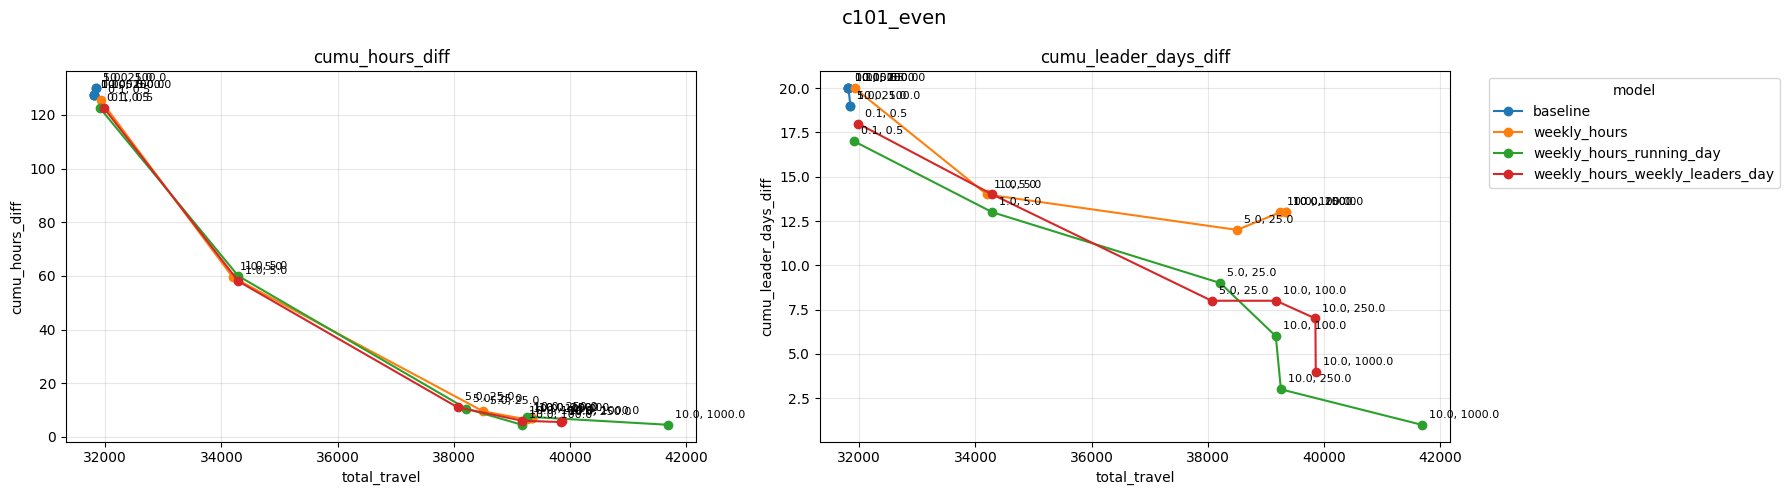

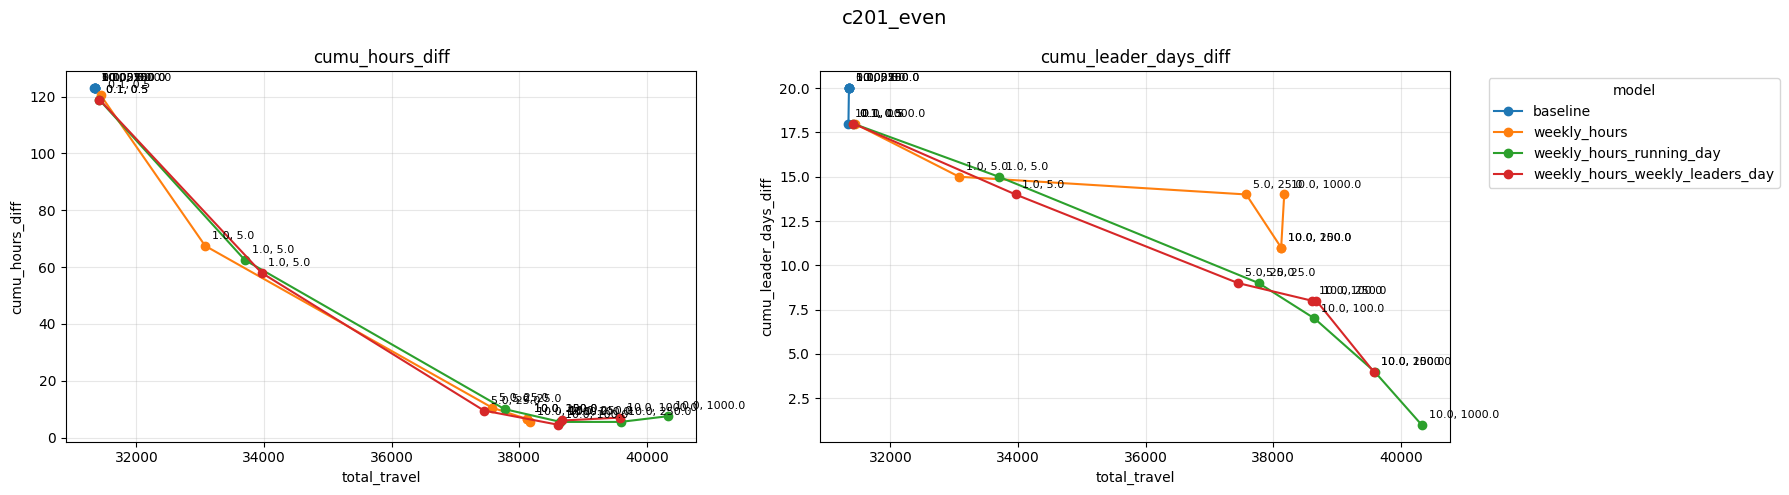

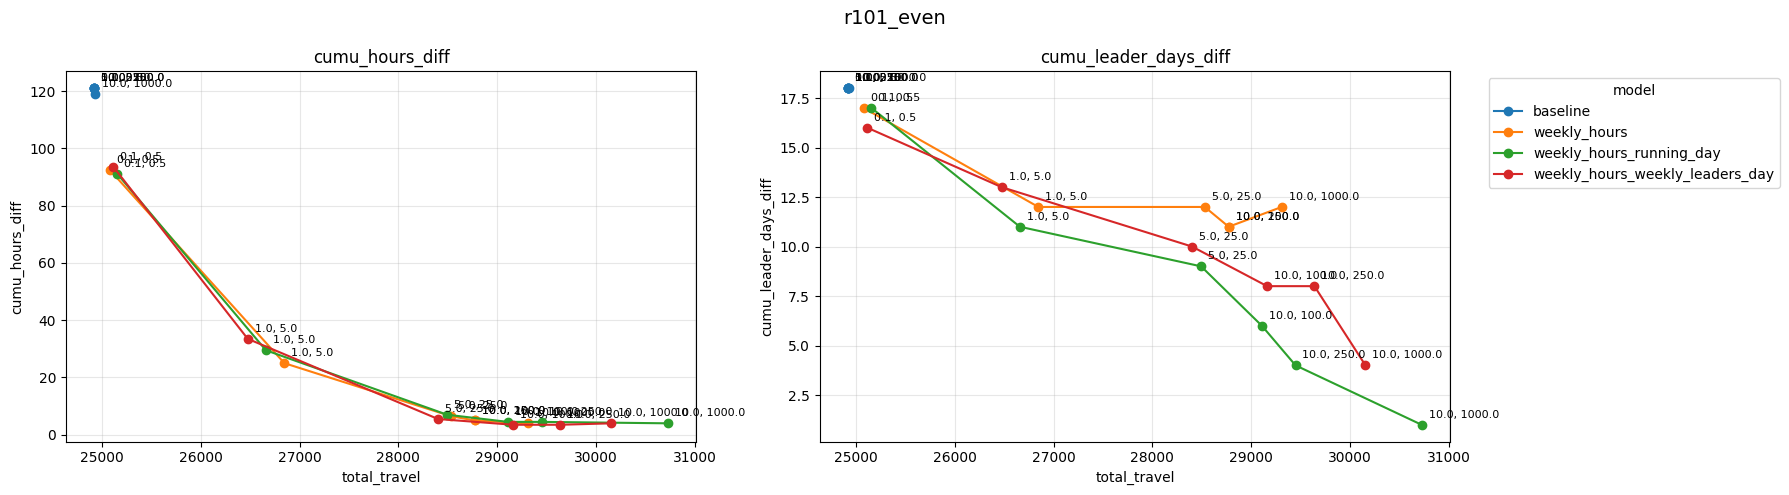

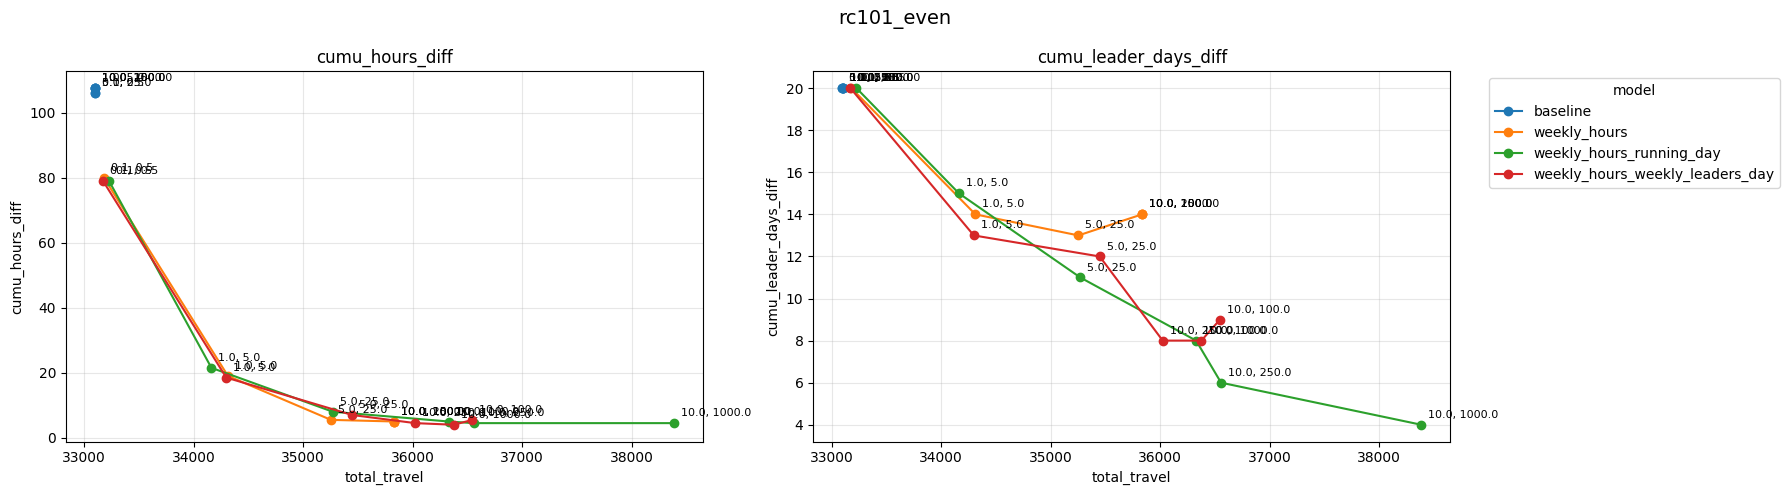

In [18]:
import matplotlib.pyplot as plt

prefixes = ["c101", "c201", "r101", "rc101"]
patterns = ["even"]
y_cols = ["cumu_hours_diff", "cumu_leader_days_diff"]

for prefix in prefixes:
    for pattern in patterns:
        key = f"{prefix}_{pattern}"

        df = summary_filtered[
            summary_filtered["instance"].str.contains(
                rf"^{key}_",
                case=False,
                na=False,
                regex=True,
            )
        ].copy()

        if df.empty:
            print(f"No rows found for {key}")
            continue

        fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharex=True)
        fig.suptitle(key, fontsize=14)

        for ax, y_col in zip(axes, y_cols):
            for model, group in df.groupby("model"):
                is_add_depot = "add_depot" in model
                group = group.sort_values("total_travel")

                ax.plot(
                    group["total_travel"],
                    group[y_col],
                    marker="o",
                    linestyle="--" if is_add_depot else "-",
                    label=model,
                )

                for _, row in group.iterrows():
                    ax.annotate(
                        f"{row['hour_penalty']}, {row['leader_penalty']}",
                        xy=(row["total_travel"], row[y_col]),
                        xytext=(5, 5),
                        textcoords="offset points",
                        fontsize=8,
                    )

            ax.set_title(y_col)
            ax.set_xlabel("total_travel")
            ax.set_ylabel(y_col)
            ax.grid(True, alpha=0.3)

        axes[-1].legend(
            title="model",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
        )

        plt.tight_layout()
        # plt.savefig(f"../../outputs/pareto_{key}.png", bbox_inches="tight")
        plt.show()

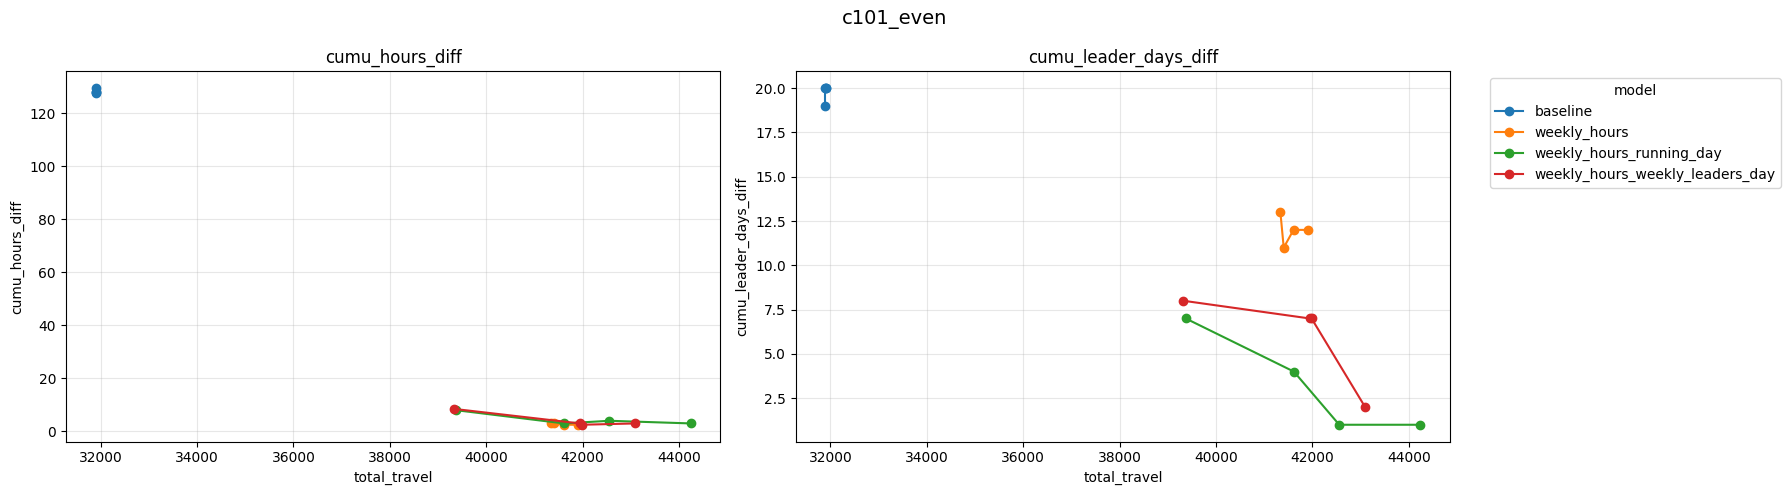

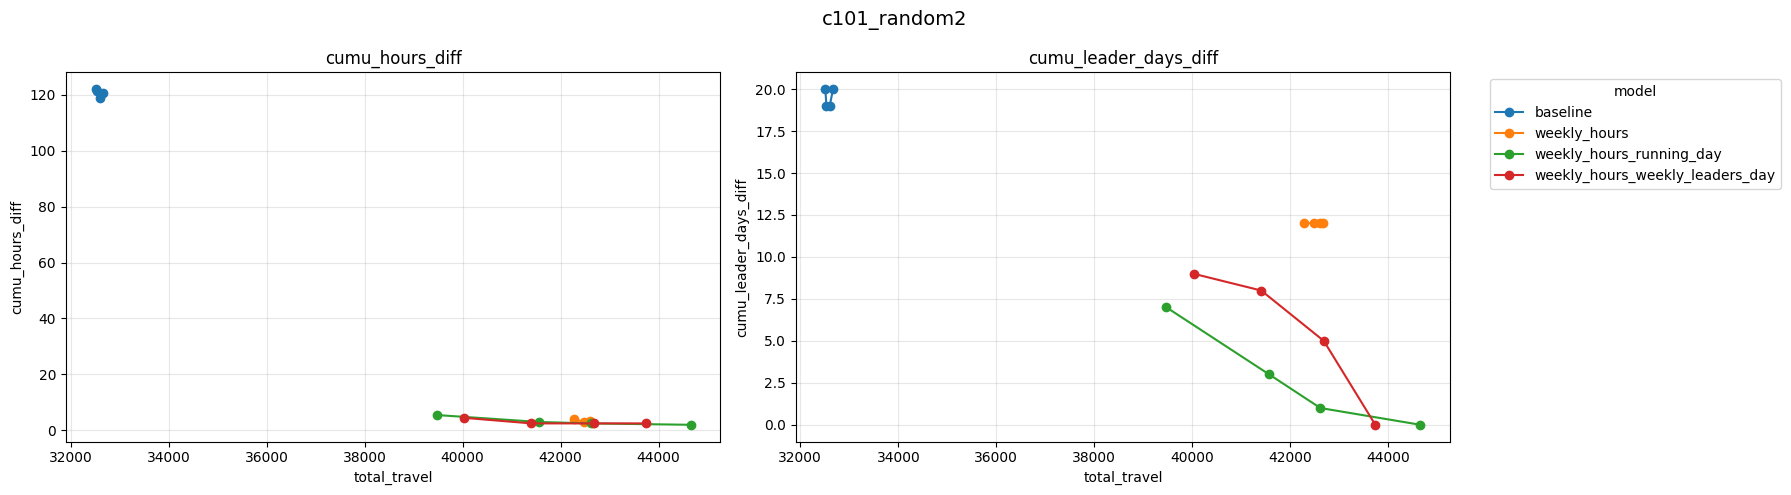

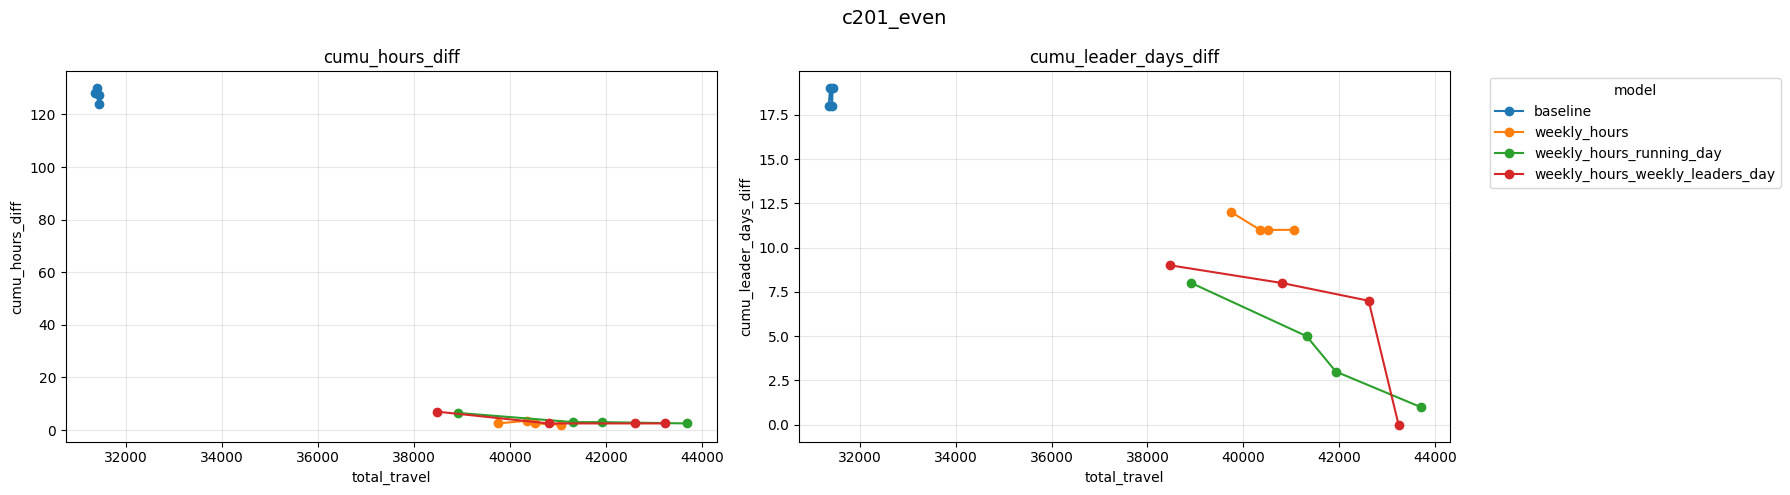

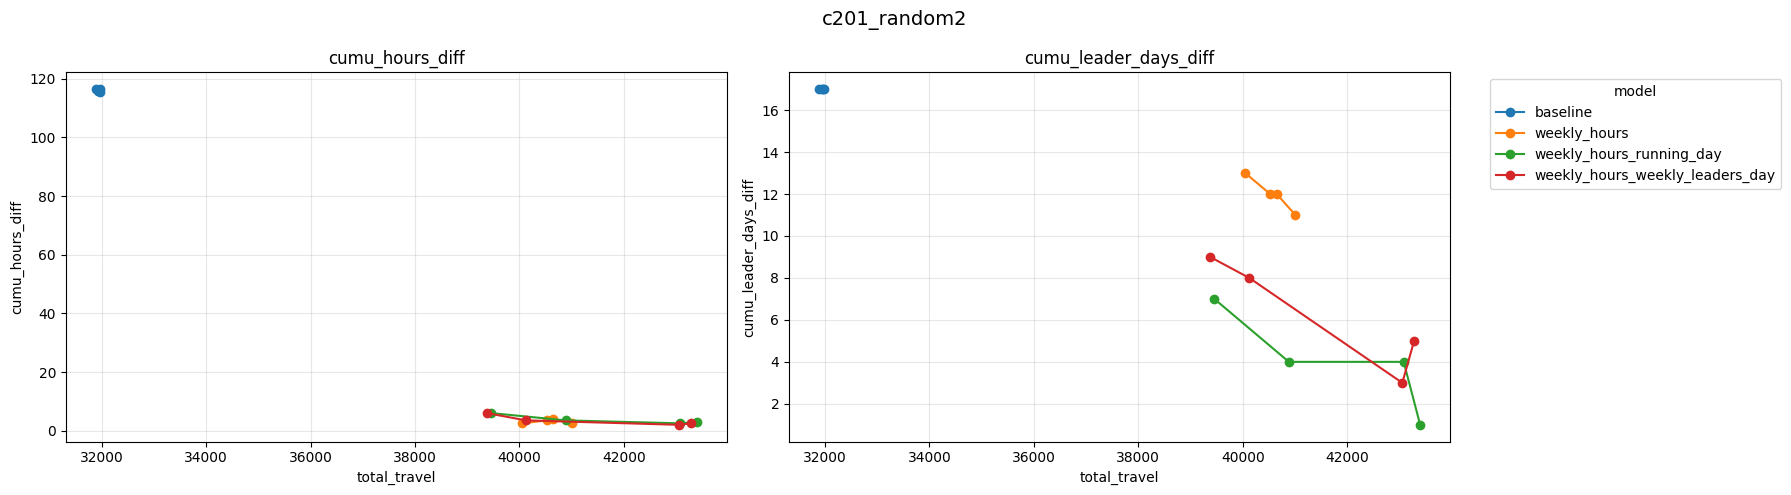

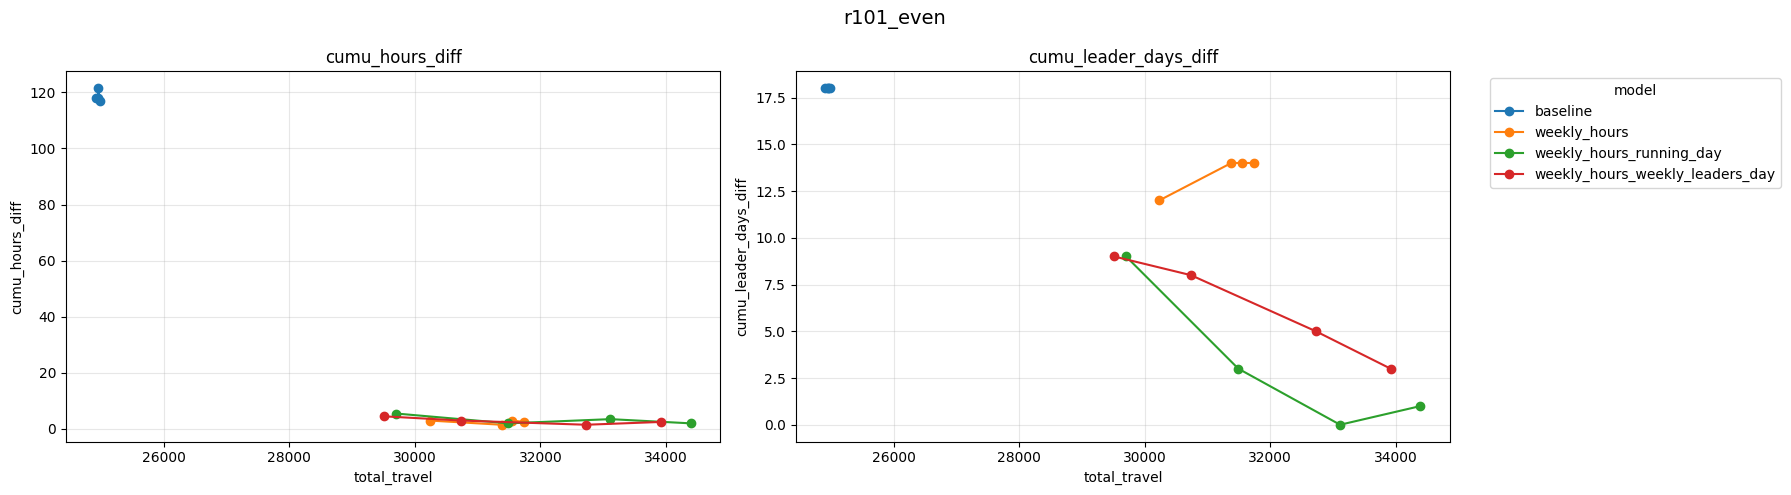

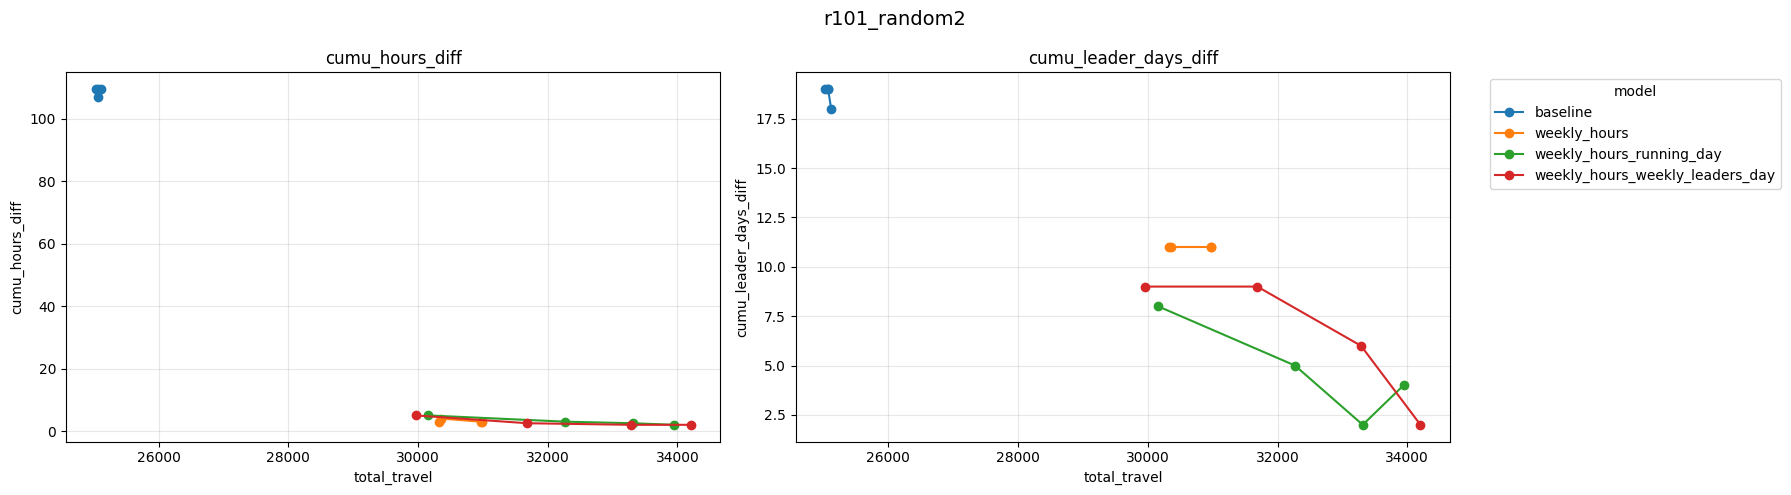

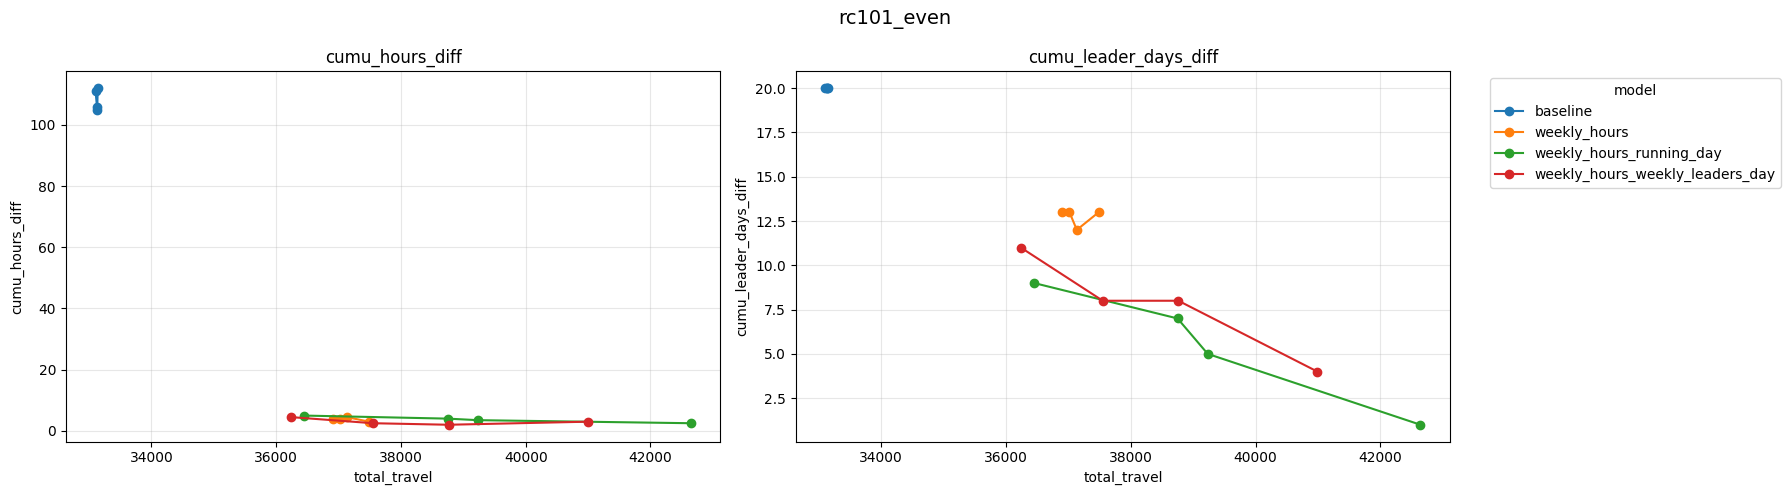

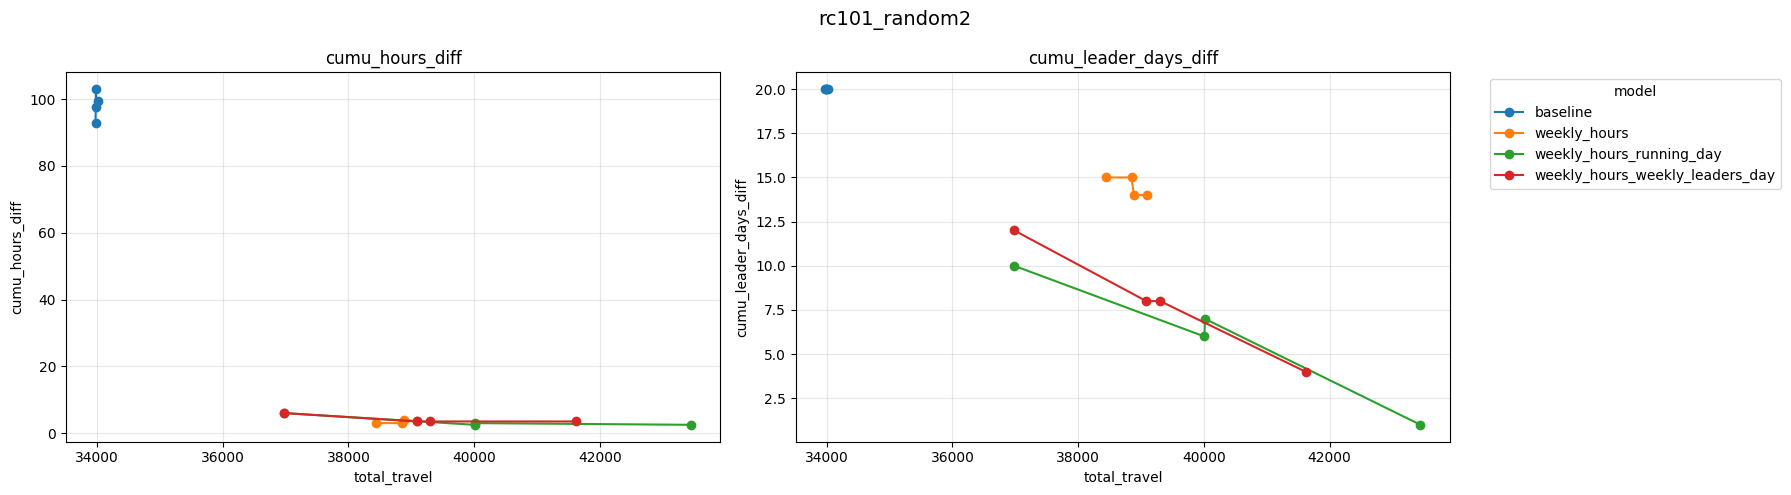

In [9]:
import matplotlib.pyplot as plt

prefixes = ["c101", "c201", "r101", "rc101"]
patterns = ["even", "random2"]
y_cols = ["cumu_hours_diff", "cumu_leader_days_diff"]

for prefix in prefixes:
    for pattern in patterns:
        key = f"{prefix}_{pattern}"

        df = summary_filtered[
            summary_filtered["instance"].str.contains(
                rf"^{key}_",
                case=False,
                na=False,
                regex=True,
            )
        ].copy()

        if df.empty:
            print(f"No rows found for {key}")
            continue

        fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharex=True)
        fig.suptitle(key, fontsize=14)

        for ax, y_col in zip(axes, y_cols):
            for model, group in df.groupby("model"):
                is_add_depot = "add_depot" in model
                group = group.sort_values("total_travel")

                ax.plot(
                    group["total_travel"],
                    group[y_col],
                    marker="o",
                    linestyle="--" if is_add_depot else "-",
                    label=model,
                )

            ax.set_title(y_col)
            ax.set_xlabel("total_travel")
            ax.set_ylabel(y_col)
            ax.grid(True, alpha=0.3)

        axes[-1].legend(
            title="model",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
        )

        plt.tight_layout()
        # plt.savefig(f"../../outputs/pareto_{key}.png", bbox_inches="tight")
        plt.show()

(baseline, add_depot)
(weekly_hours, add_depot_weekly_hours)
(weekly_hours_weekly_leaders_day, add_depot_weekly_hours_weekly_leaders)
(weekly_hours_running_day, add_depot_weekly_hours_running)

In [ ]:
# keep only rows where model is in:
# (baseline, add_depot)
# (weekly_hours, add_depot_weekly_hours)
# (weekly_hours_weekly_leaders_day, add_depot_weekly_hours_weekly_leaders)
# (weekly_hours_running_day, add_depot_weekly_hours_running)
# valid_models = {
#     "baseline",
#     "add_depot",
#     "weekly_hours",
#     "add_depot_weekly_hours",
#     "weekly_hours_weekly_leaders_day",
#     "add_depot_weekly_hours_weekly_leaders",
#     "weekly_hours_running_day",
#     "add_depot_weekly_hours_running"
# }
# summary_filtered = summary_all[summary_all["model"].isin(valid_models)].copy()
# summary_filtered.head(12)

,instance,total_travel,cumu_hours_diff,cumu_leader_days_diff,cumu_leaders_diff,prefix,model
0,c101_even_4week,31861.0,128.5,20.0,38.0,c101_even,baseline
1,c101_even_4week_add_depot,33435.0,123.5,11.0,0.0,c101_even,add_depot
3,c101_even_4week_add_depot_weekly_hours,43561.0,2.0,9.0,0.0,c101_even,add_depot_weekly_hours
4,c101_even_4week_add_depot_weekly_hours_running,45833.0,2.0,0.0,0.0,c101_even,add_depot_weekly_hours_running
5,c101_even_4week_add_depot_weekly_hours_weekly_...,46521.0,2.0,1.0,0.0,c101_even,add_depot_weekly_hours_weekly_leaders
7,c101_even_4week_weekly_hours,42044.0,3.5,14.0,22.0,c101_even,weekly_hours
9,c101_even_4week_weekly_hours_running_day,42966.0,2.5,0.0,7.0,c101_even,weekly_hours_running_day
11,c101_even_4week_weekly_hours_weekly_leaders_day,41911.0,2.5,3.0,12.0,c101_even,weekly_hours_weekly_leaders_day
12,c101_random2_4week,32609.0,119.0,19.0,44.0,c101_random2,baseline
13,c101_random2_4week_add_depot,34008.0,114.5,12.0,0.0,c101_random2,add_depot


loop through strings [c101 c201 r101 rc101] + '_' + [even, random2], one plot for each combination
for each string, filter summary_all to only rows where instance contains that string
make line plot with each row of data. Let x = total_travel, y in ['cumu_hours_diff', 'cumu_leader_days_diff', 'cumu_leaders_diff'] (three subplots), one line per string, with legend.

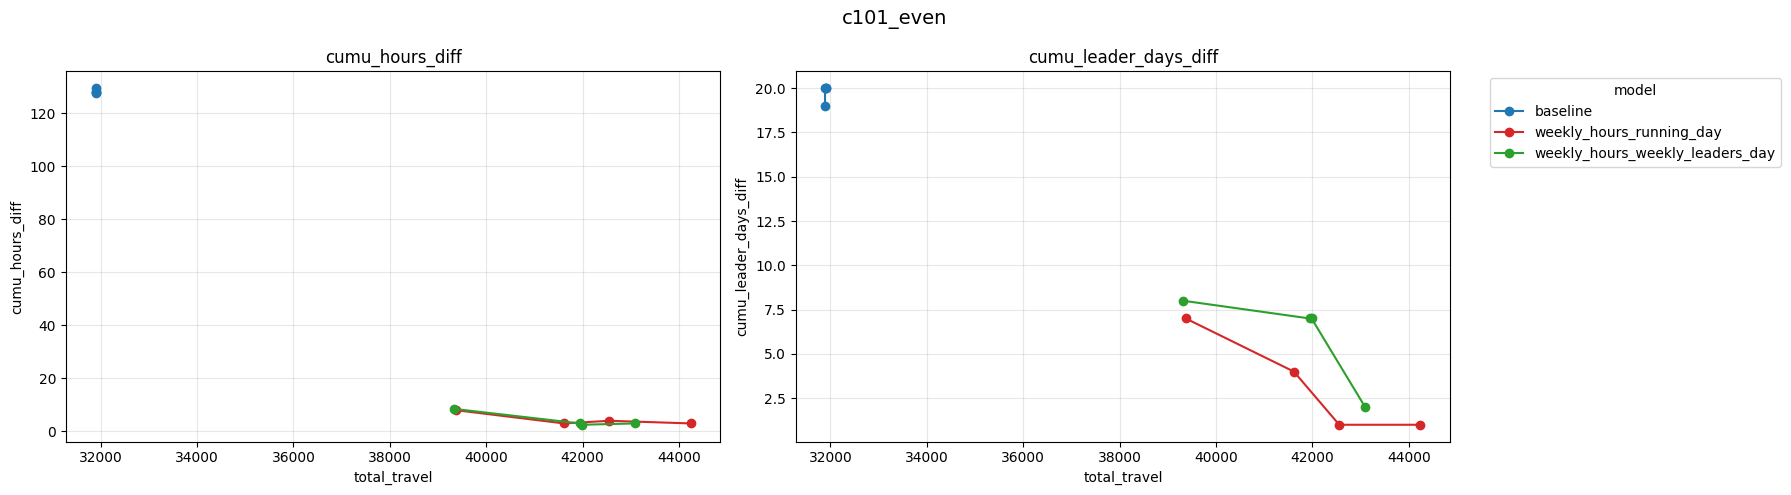

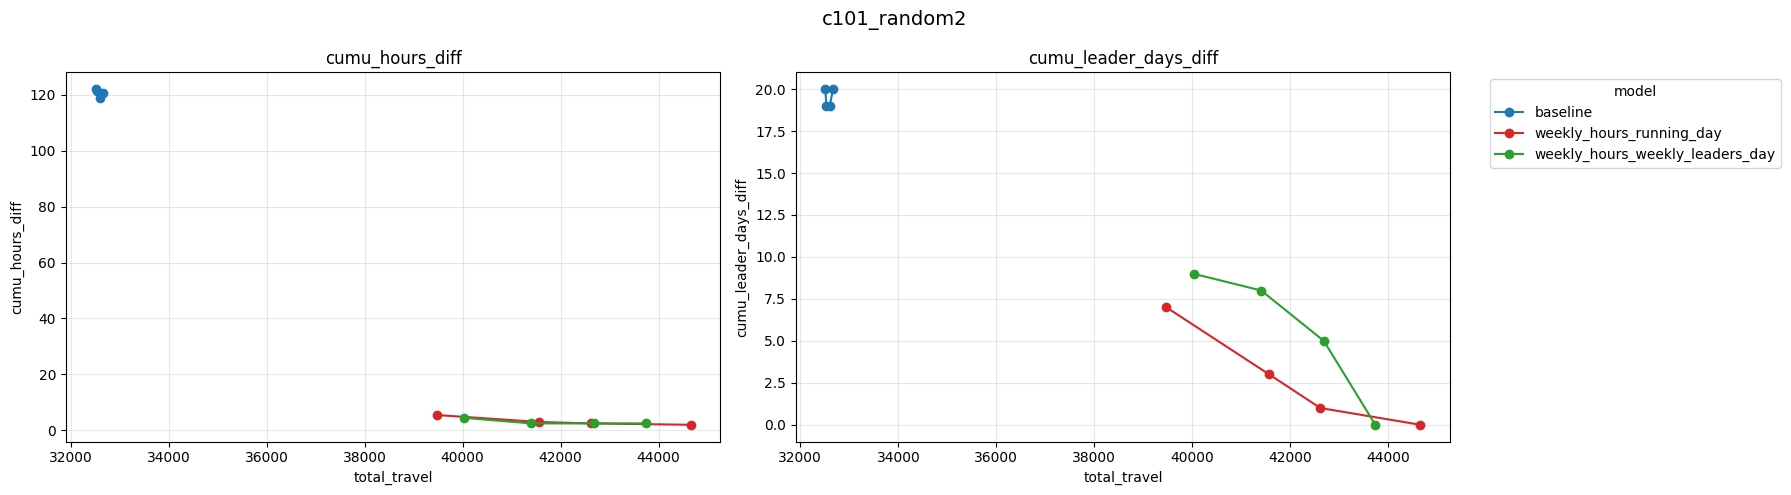

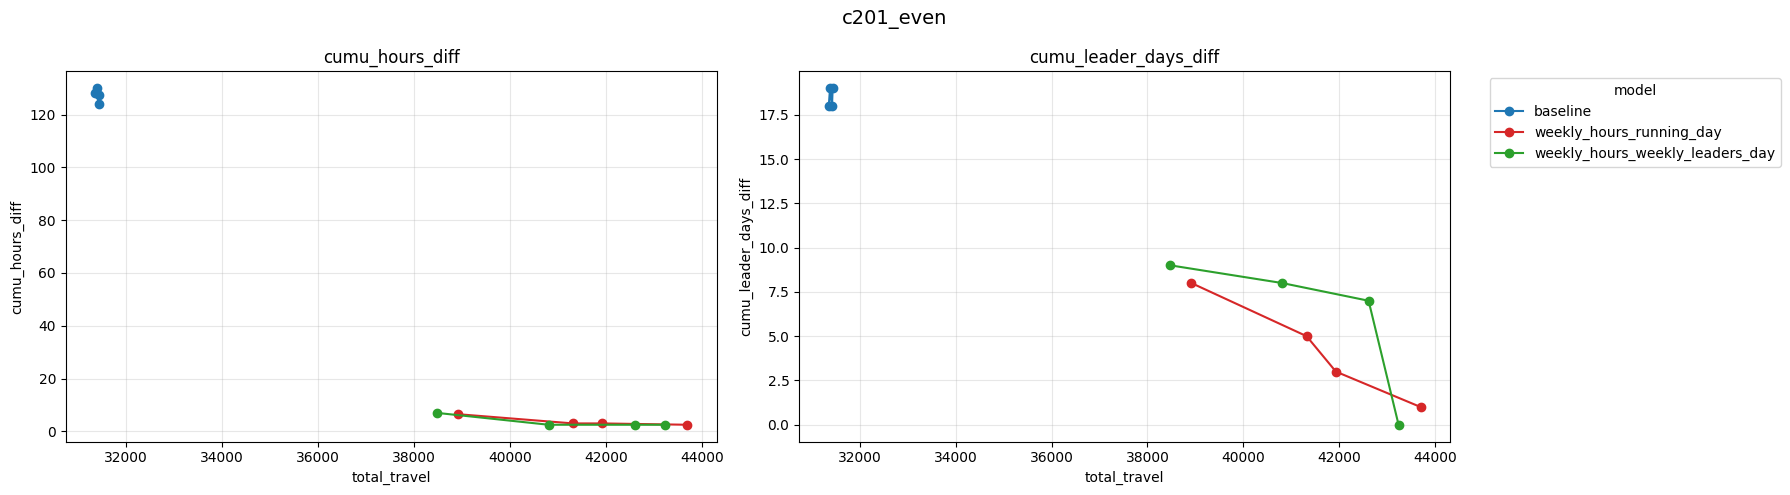

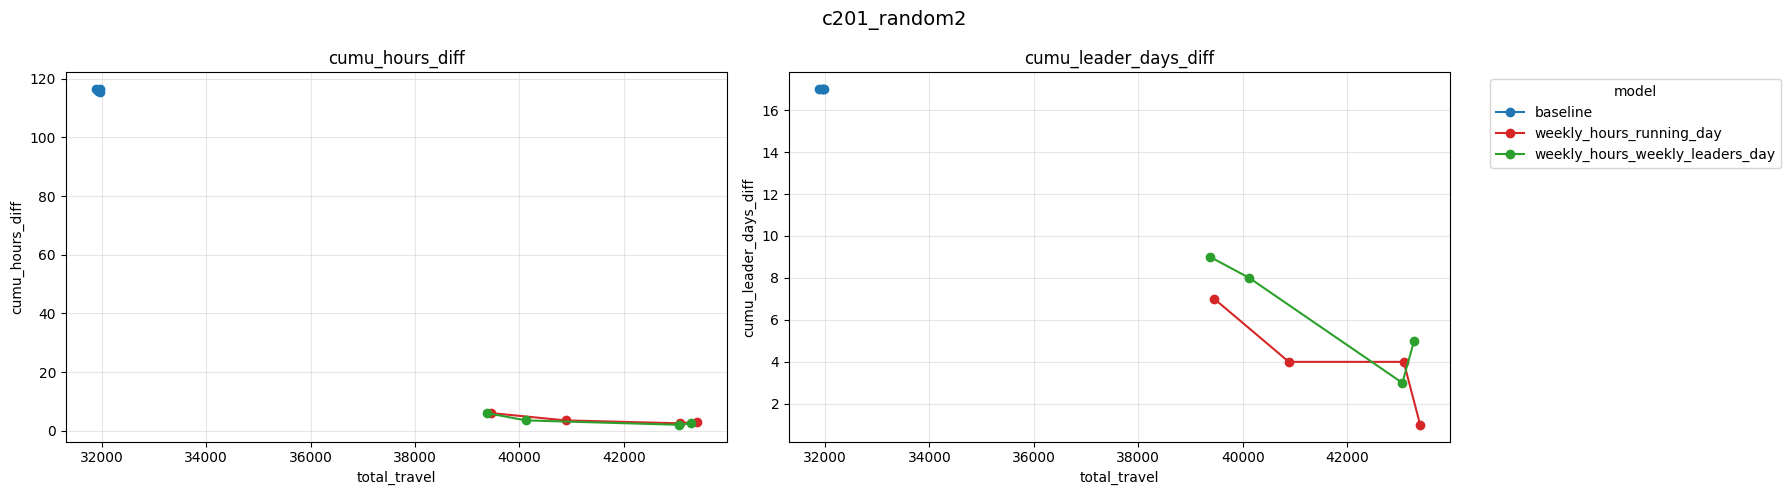

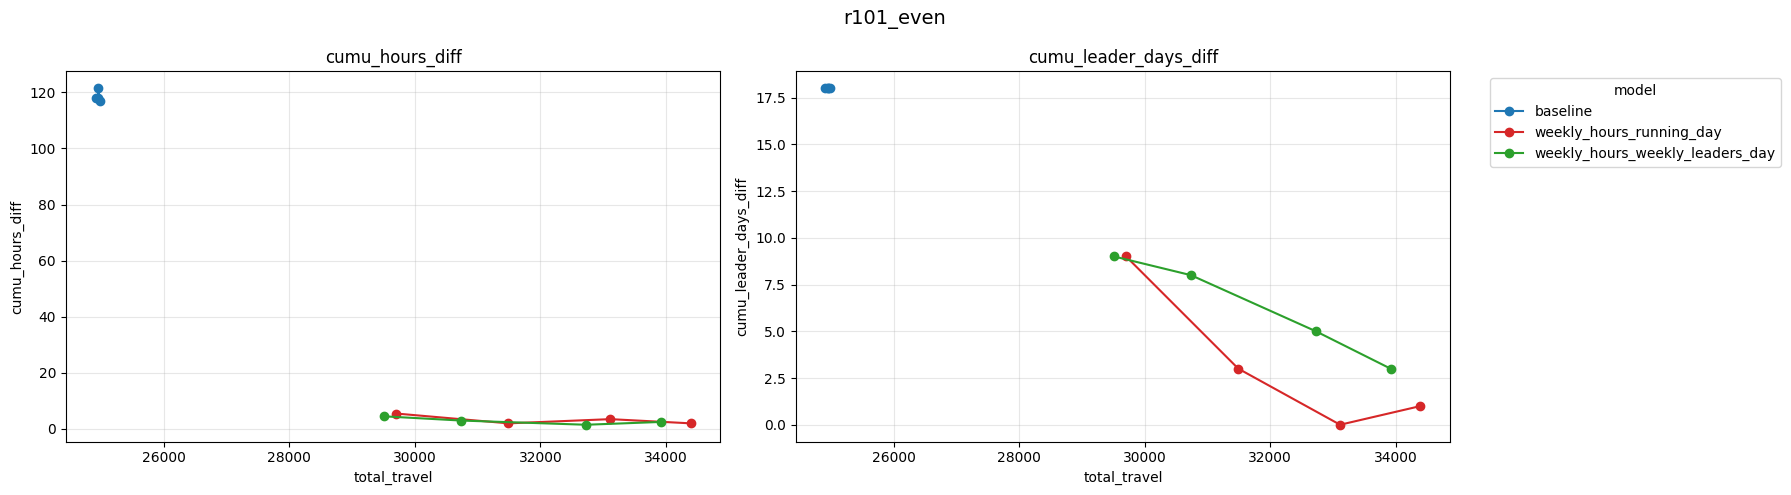

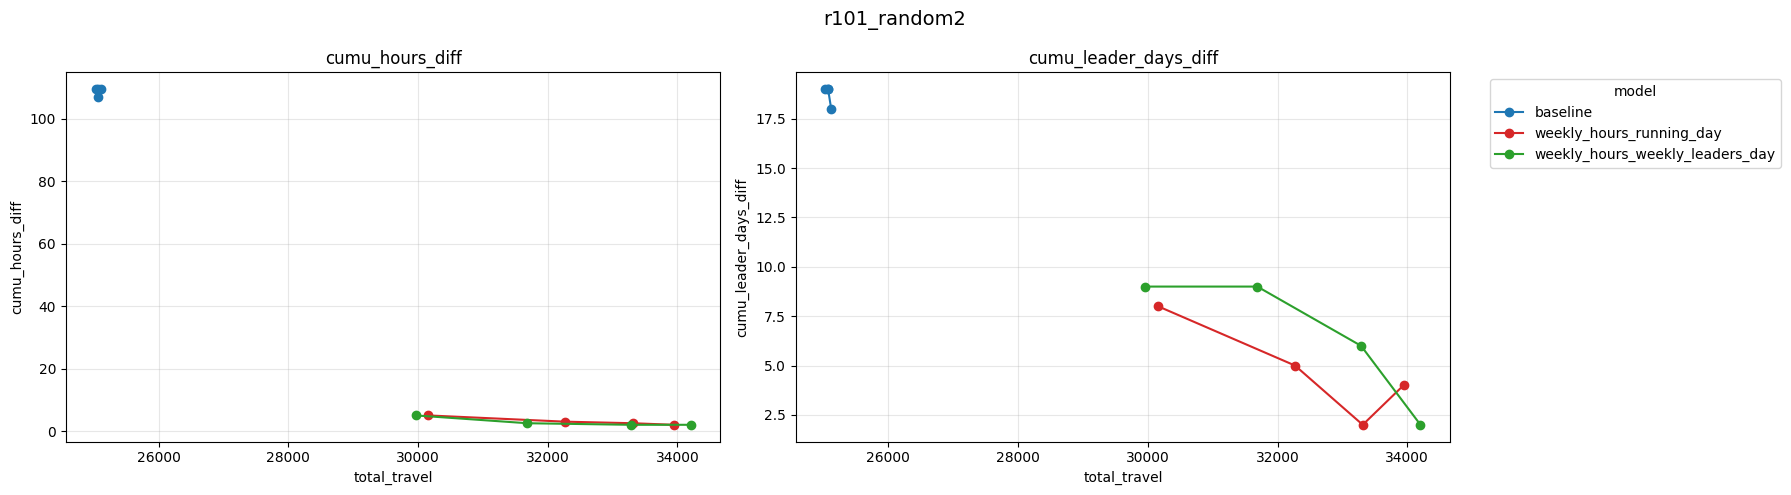

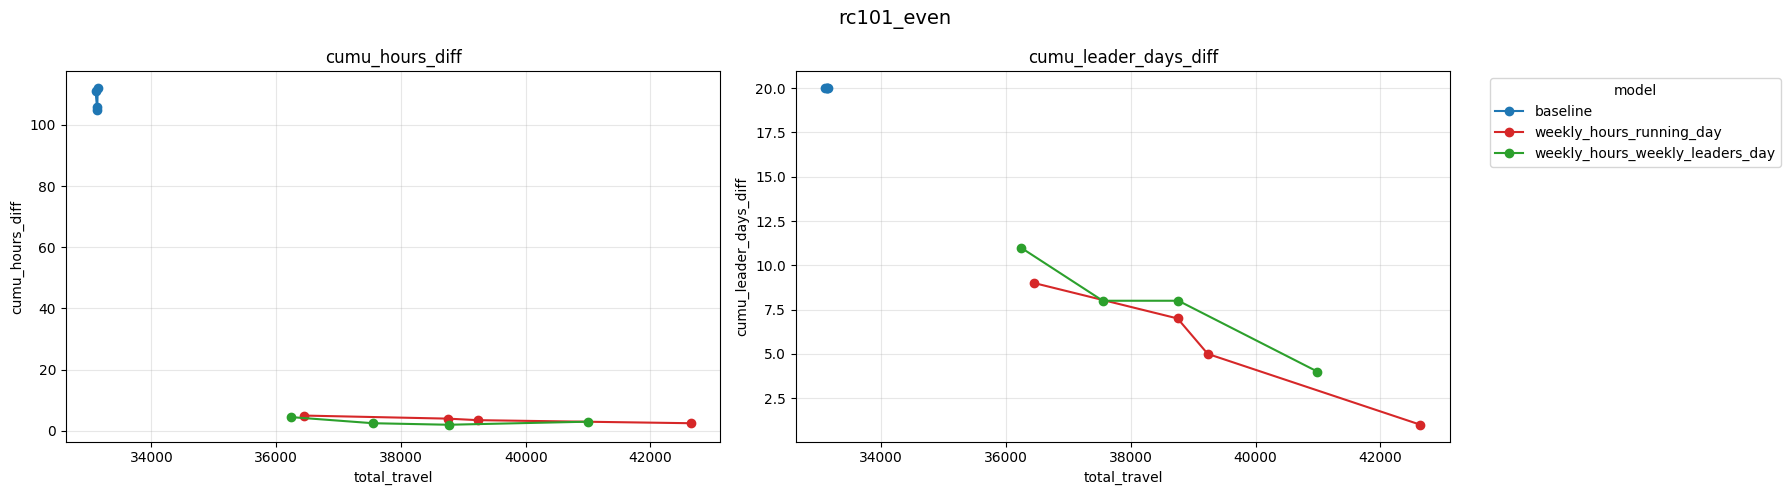

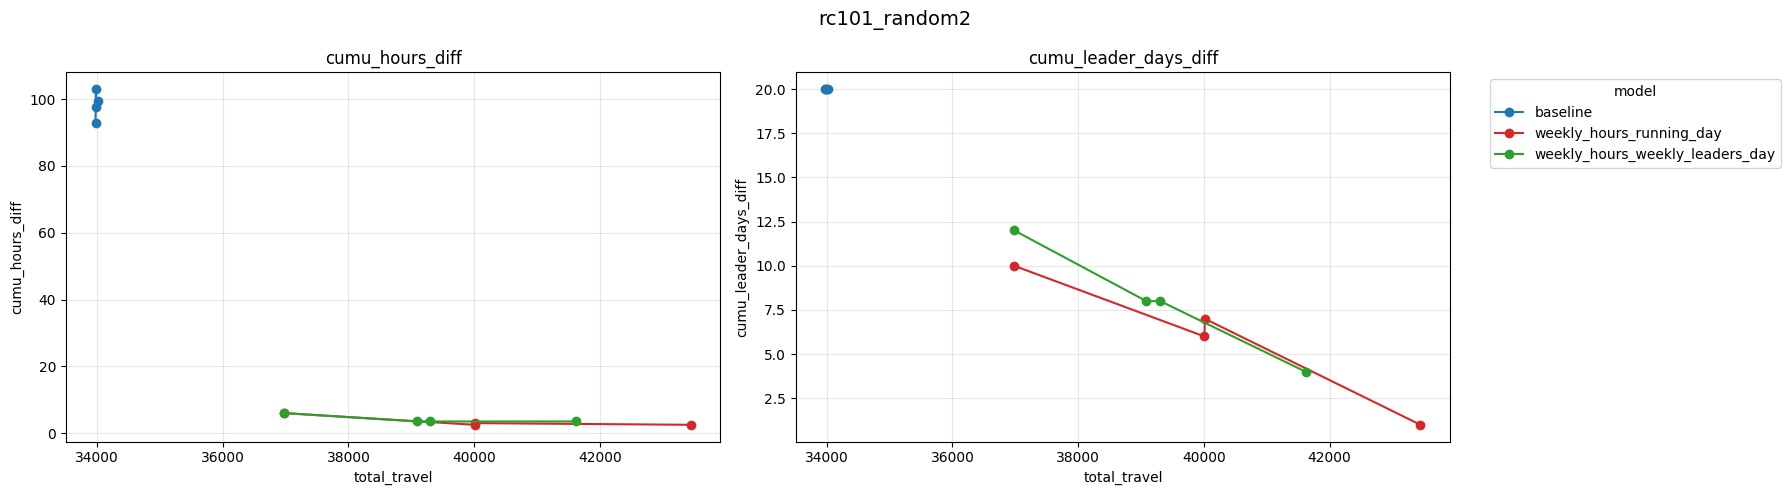

In [7]:
import matplotlib.pyplot as plt

prefixes = ["c101", "c201", "r101", "rc101"]
patterns = ["even", "random2"]
y_cols = ["cumu_hours_diff", "cumu_leader_days_diff"]

model_color_group = {
    "baseline": "baseline",
    "add_depot": "baseline",

    "weekly_hours": "weekly_hours",
    "add_depot_weekly_hours": "weekly_hours",

    "weekly_hours_weekly_leaders_day": "weekly_hours_weekly_leaders_day",
    "add_depot_weekly_hours_weekly_leaders": "weekly_hours_weekly_leaders_day",

    "weekly_hours_running_day": "weekly_hours_running_day",
    "add_depot_weekly_hours_running": "weekly_hours_running_day",
}

color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
group_names = list(dict.fromkeys(model_color_group.values()))
group_colors = {
    group: color_cycle[i % len(color_cycle)]
    for i, group in enumerate(group_names)
}

for prefix in prefixes:
    for pattern in patterns:
        key = f"{prefix}_{pattern}"

        df = summary_filtered[
            summary_filtered["instance"].str.contains(
                rf"^{key}_",
                case=False,
                na=False,
                regex=True,
            )
        ].copy()

        if df.empty:
            print(f"No rows found for {key}")
            continue

        fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharex=True)
        fig.suptitle(key, fontsize=14)

        for ax, y_col in zip(axes, y_cols):
            for model, group in df.groupby("model"):
                is_add_depot = "add_depot" in model
                group = group.sort_values("total_travel")

                color_group = model_color_group.get(model, model)
                color = group_colors.setdefault(
                    color_group,
                    color_cycle[len(group_colors) % len(color_cycle)]
                )

                ax.plot(
                    group["total_travel"],
                    group[y_col],
                    marker="o",
                    linestyle="--" if is_add_depot else "-",
                    color=color,
                    label=model,
                )

            ax.set_title(y_col)
            ax.set_xlabel("total_travel")
            ax.set_ylabel(y_col)
            ax.grid(True, alpha=0.3)

        axes[-1].legend(
            title="model",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
        )

        plt.tight_layout()
        plt.savefig(f"../../outputs/pareto_{key}.png", bbox_inches="tight")
        plt.show()

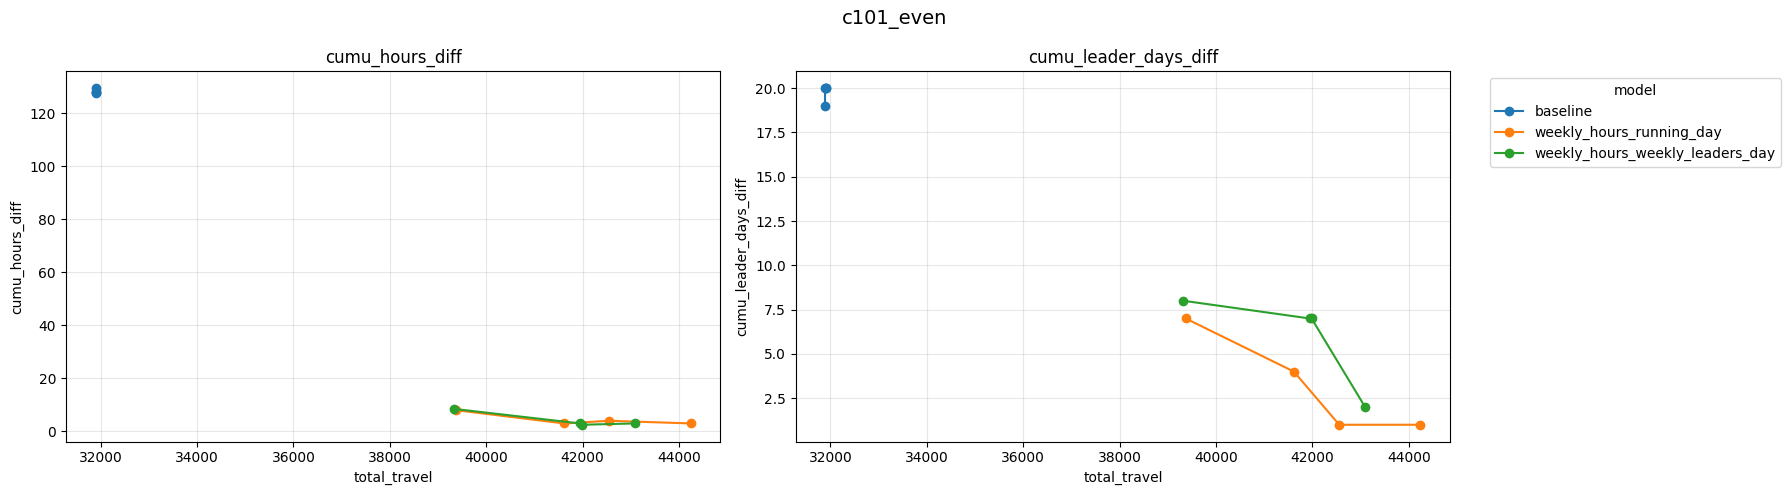

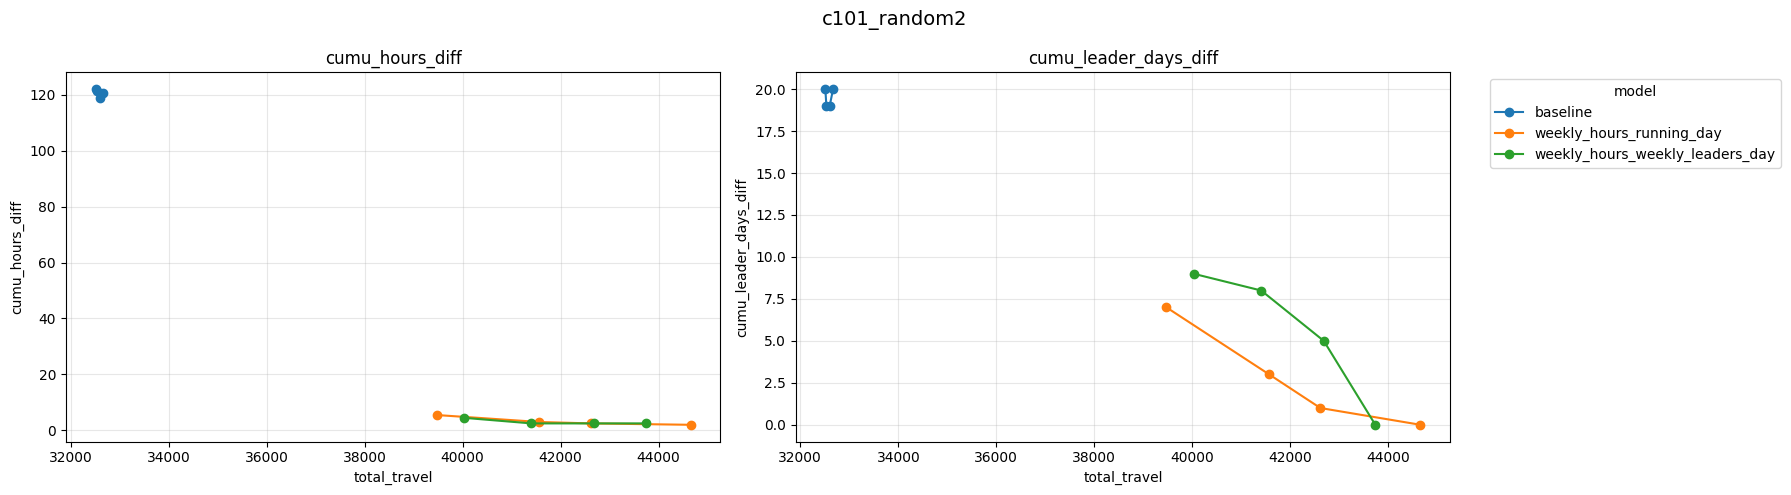

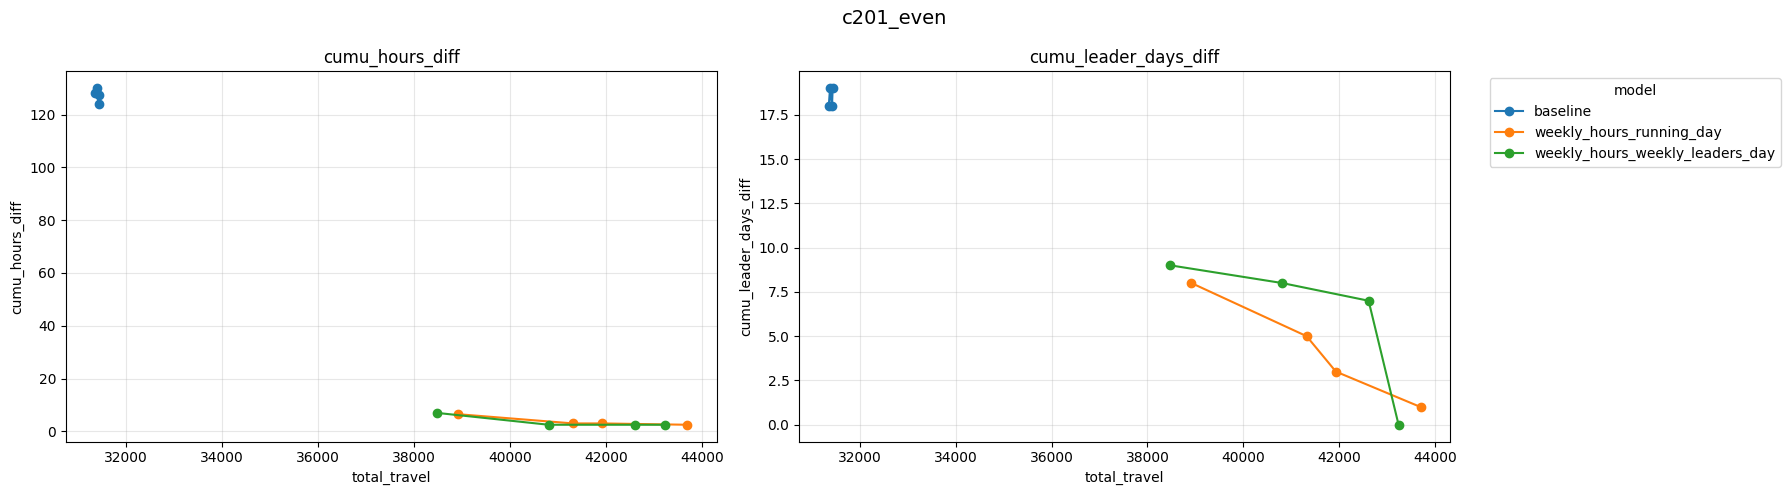

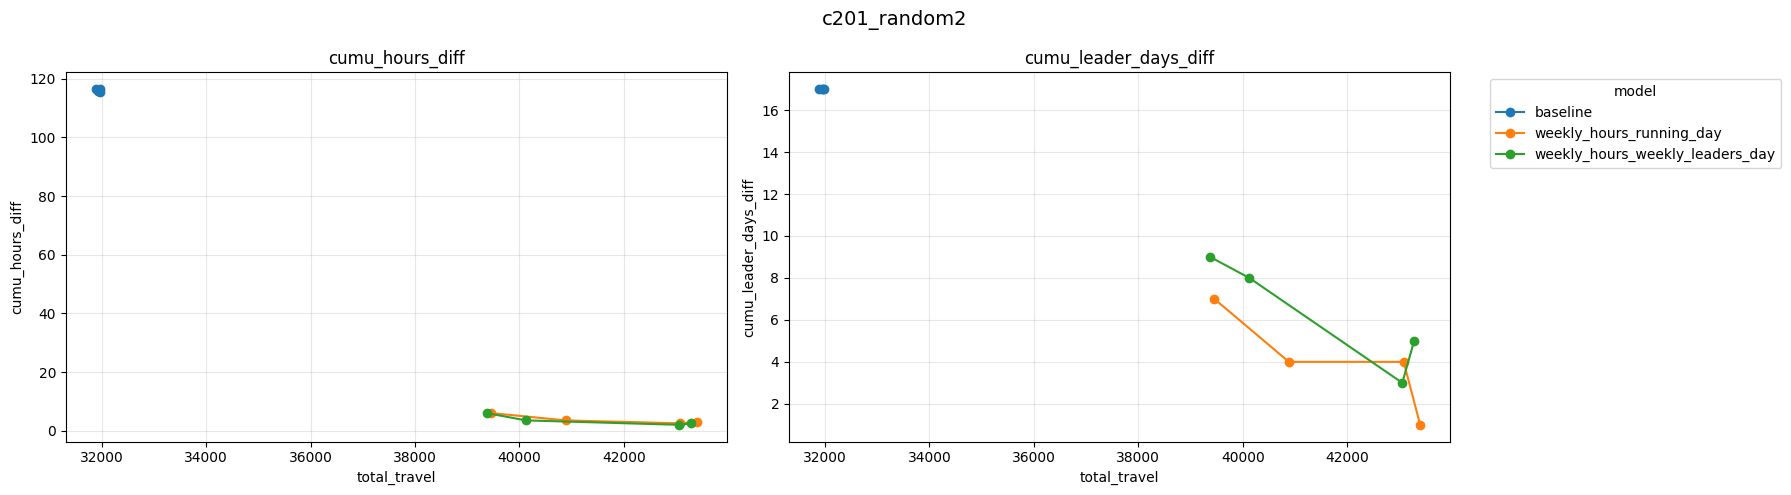

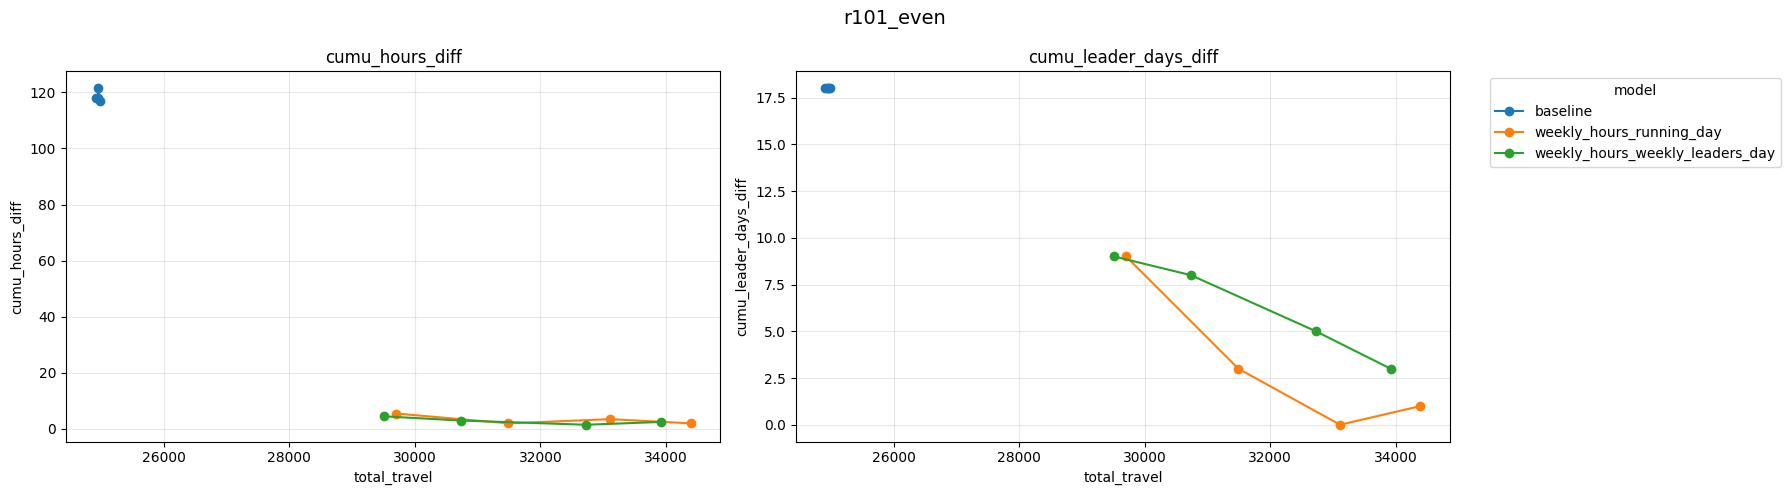

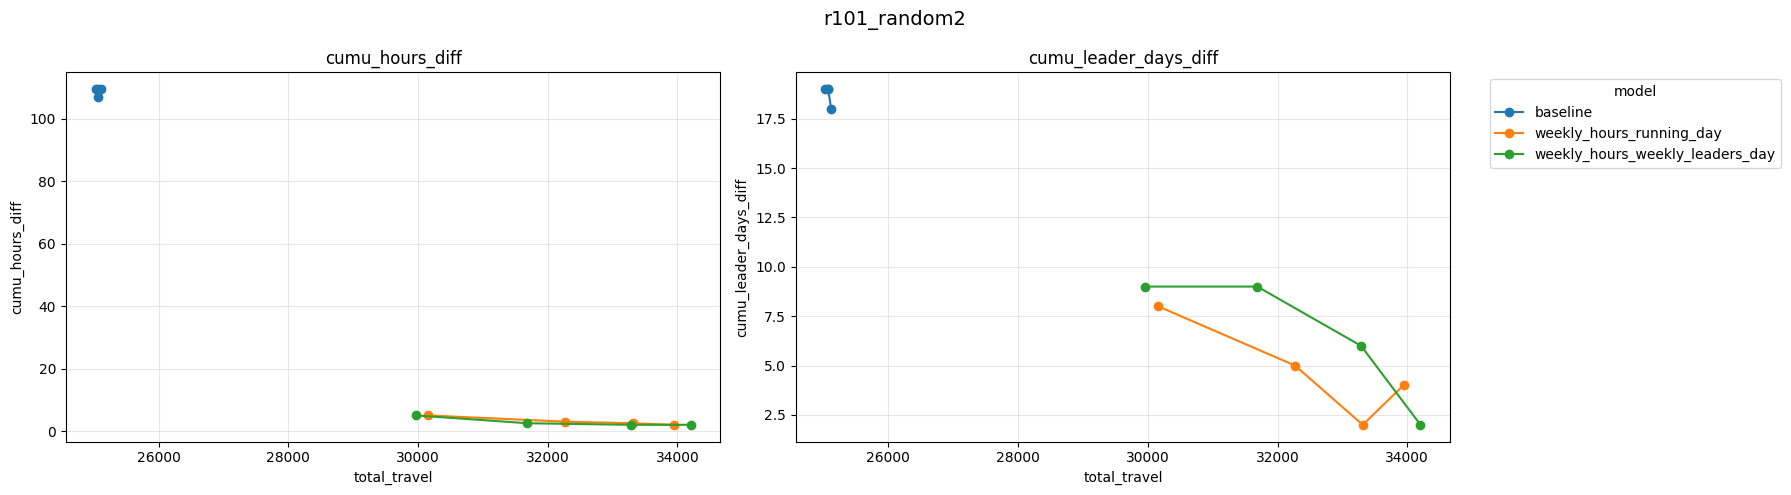

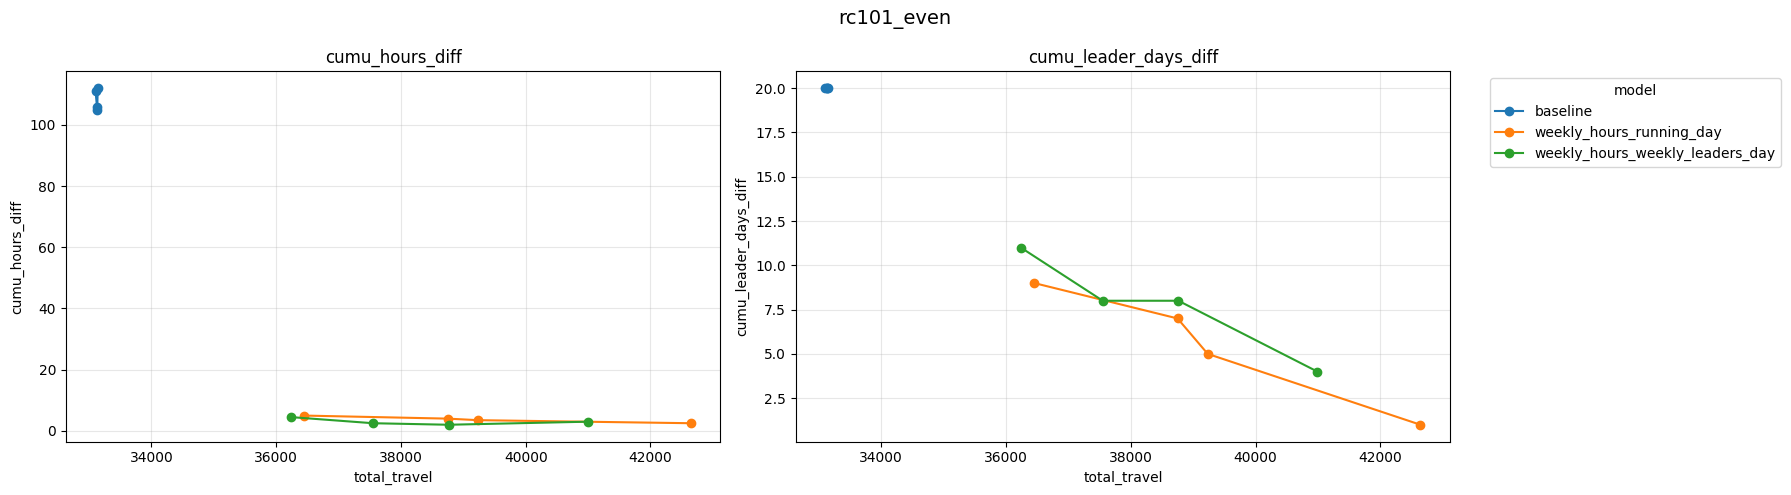

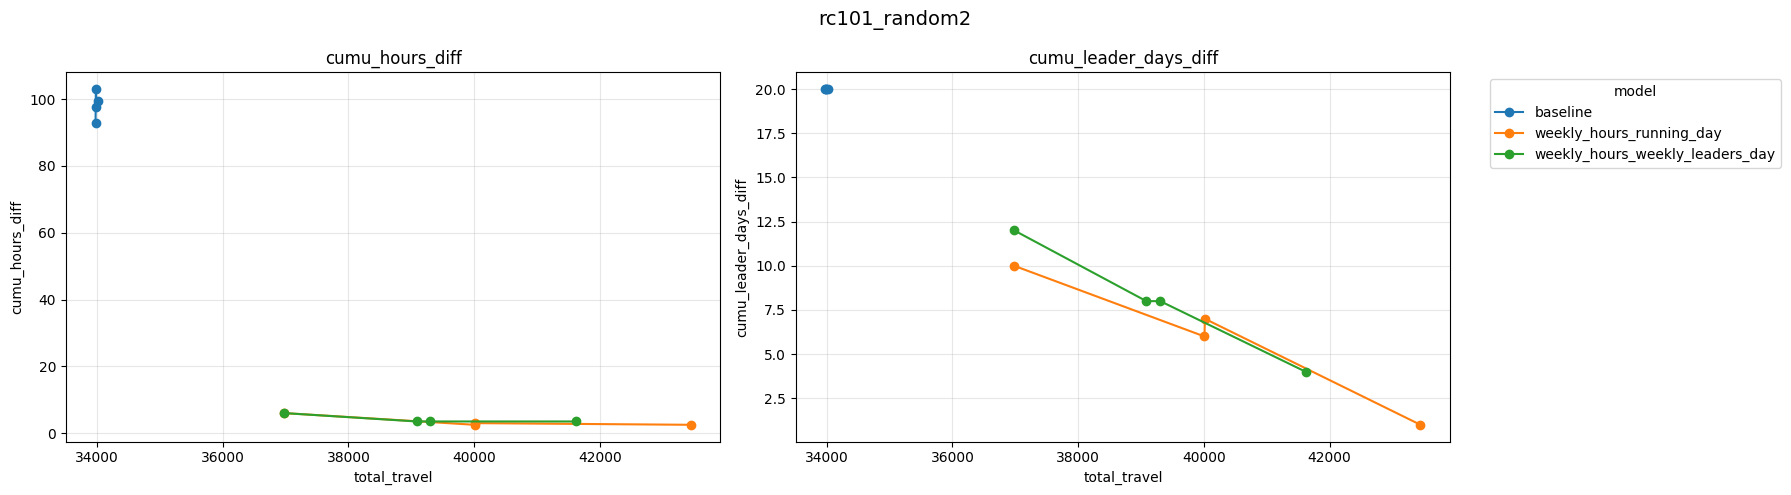

In [8]:
import matplotlib.pyplot as plt

prefixes = ["c101", "c201", "r101", "rc101"]
patterns = ["even", "random2"]
y_cols = ["cumu_hours_diff", "cumu_leader_days_diff"]

for prefix in prefixes:
    for pattern in patterns:
        key = f"{prefix}_{pattern}"

        df = summary_filtered[
            summary_filtered["instance"].str.contains(
                rf"^{key}_",
                case=False,
                na=False,
                regex=True,
            )
        ].copy()

        if df.empty:
            print(f"No rows found for {key}")
            continue

        fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharex=True)
        fig.suptitle(key, fontsize=14)

        for ax, y_col in zip(axes, y_cols):
            for model, group in df.groupby("model"):
                is_add_depot = "add_depot" in model

                if y_col == "cumu_leaders_diff" and is_add_depot:
                    continue

                group = group.sort_values("total_travel")

                ax.plot(
                    group["total_travel"],
                    group[y_col],
                    marker="o",
                    linestyle="--" if is_add_depot else "-",
                    label=model,
                )

            ax.set_title(y_col)
            ax.set_xlabel("total_travel")
            ax.set_ylabel(y_col)
            ax.grid(True, alpha=0.3)

        axes[-1].legend(
            title="model",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
        )

        plt.tight_layout()
        plt.savefig(f"../../outputs/pareto_{key}.png")
        plt.show()